In [1]:
import sys
sys.path.append("../../src")

import numpy as np
from numba import njit
from scipy.stats import ortho_group
from tqdm import tqdm
import matplotlib.pyplot as plt
from skimage import data

from visualization_utils import display_matrix, plot_bss_comparison, subplot_1D_signals
from bss_utils import generate_uncorrelated_uniform_sources, addWGN

# Helper Functions

In [2]:
@njit(parallel=True)
def ComputeSNR(S_original, S_noisy):
    """
    Calculate the Signal-to-Noise Ratio (SNR) for each source channel.
    
    Args:
        S_original (ndarray): Ground truth source matrix of shape (n_sources, n_samples).
        S_noisy (ndarray): Estimated or noisy source matrix of shape (n_sources, n_samples).
        
    Returns:
        ndarray: SNR values in decibels (dB) for each channel.
    """
    # Residual noise calculation
    N_hat = S_original - S_noisy
    
    # Power calculation per channel (sum of squares)
    N_P = (N_hat**2).sum(axis=1)
    S_P = (S_original**2).sum(axis=1)
    
    # Standard SNR formula in log scale
    snr = 10 * np.log10(S_P / N_P)
    return snr

def outer_prod_broadcasting(A, B):
    """
    Compute the pairwise outer product between columns of two matrices using broadcasting.
    
    This is used to efficiently calculate cross-correlation terms across all channel pairs.
    """
    return A[..., None] * B[:, None]

def find_permutation_between_source_and_estimation(S, Y):
    """
    Identify the best 1-to-1 mapping between estimated outputs and ground truth sources.
    
    BSS algorithms suffer from permutation ambiguity. This function uses the Pearson 
    correlation absolute values to find which output corresponds to which source.

    Args:
        S (ndarray): Original source matrix (n_sources, n_samples).
        Y (ndarray): Estimated source matrix (n_sources, n_samples).

    Returns:
        ndarray: Indices of Y that best match the order of S.
    """
    # Calculate pairwise correlation using broadcasting trick
    # We normalize by the norms to get the correlation coefficient
    correlation_numerator = np.abs(outer_prod_broadcasting(Y.T, S.T).sum(axis=0))
    normalization = (np.linalg.norm(S, axis=1) * np.linalg.norm(Y, axis=1))
    
    # Find the index of the estimate with the highest correlation for each source
    perm = np.argmax(correlation_numerator / normalization, axis=0)
    return perm

def signed_and_permutation_corrected_sources(S, Y):
    """
    Correct for both permutation and sign ambiguity in the estimated sources.
    
    In ICA/BSS, the output Y_i could be -S_j. This function reorders Y and flips
    the signs so that the output matches the ground truth S as closely as possible.

    Args:
        S (ndarray): Ground truth source matrix (n_sources, n_samples).
        Y (ndarray): Uncorrected estimation matrix (n_sources, n_samples).

    Returns:
        ndarray: Reordered and sign-flipped estimations.
    """
    # 1. Find the permutation (mapping)
    perm = find_permutation_between_source_and_estimation(S, Y)
    
    # 2. Determine the sign by looking at the dot product of the matched pairs
    # If the dot product is negative, we need to flip the sign (multiply by -1)
    matched_Y = Y[perm, :]
    signs = np.sign((matched_Y * S).sum(axis=1))
    
    return signs[:, np.newaxis] * matched_Y

@njit
def ComputeSINR(S, Y):
    """
    Calculate the Signal-to-Interference-plus-Noise Ratio (SINR) in dB.
    
    This function performs internal Z-score normalization to handle scale ambiguity,
    corrects for permutation/sign via correlation, and computes the ratio of 
    signal power to reconstruction error.

    Args:
        S (ndarray): Ground truth source matrix.
        Y (ndarray): Estimated source matrix.

    Returns:
        float: The aggregate SINR value in dB.
    """
    N_Sources = S.shape[0]
    
    # Numba-friendly normalization: avoid keepdims which is not fully supported
    S_normalized = np.zeros_like(S)
    Y_normalized = np.zeros_like(Y)
    
    for i in range(N_Sources):
        # Subtract mean and divide by std (Z-score) for both S and Y
        s_i = S[i, :]
        S_normalized[i, :] = (s_i - np.mean(s_i)) / (np.std(s_i) + 1e-9)
        
        y_i = Y[i, :]
        Y_normalized[i, :] = (y_i - np.mean(y_i)) / (np.std(y_i) + 1e-9)
        
    # Compute the correlation matrix between all pairs
    corr = np.dot(Y_normalized, S_normalized.T) 
    
    # Solve permutation ambiguity: find which Y index matches which S index
    perm = np.zeros(N_Sources, dtype=np.int64)
    for i in range(N_Sources):
        perm[i] = np.argmax(np.abs(corr[:, i]))
        
    # Solve sign ambiguity: check if the matched signals are inverted
    signs = np.zeros((N_Sources, 1))
    for i in range(N_Sources):
        signs[i, 0] = np.sign(corr[perm[i], i])
    
    # Create the corrected estimate (aligned with S)
    Y_normalized_corrected = signs * Y_normalized[perm, :]
    
    # Calculate the error (Interference + Noise)
    E = Y_normalized_corrected - S_normalized
    
    # Calculate final SINR using Frobenius norms
    MSE = np.linalg.norm(E) ** 2
    SigPow = np.linalg.norm(S_normalized) ** 2
    
    sinr_val = 10 * np.log10(SigPow / (MSE + 1e-9))
    return sinr_val

# Generate Sources and Mix Them (5 by 3 case)

In [3]:
# # Load images
img1 = data.gravel().astype(float)
img2 = data.brick().astype(float)

# Standardize sizes (e.g., crop or resize to the smallest image)
min_h = min(img1.shape[0], img2.shape[0])
min_w = min(img1.shape[1], img2.shape[1])

# Crop and flatten into vectors
s1 = img1[:min_h, :min_w].flatten() / 255
s2 = img2[:min_h, :min_w].flatten() / 255

# Combine into source matrix S (3 sources)
S = np.vstack([s1, s2])

# Map to -1, 1 range
# S = (S - S.mean(axis=1, keepdims=True)) / S.std(axis=1, keepdims=True)
S = (S - S.min(1, keepdims = True)) / (S.max(1, keepdims = True) - S.min(1, keepdims = True))
S = 2 * S - 1

In [4]:
def visualize_flattened_images(I, imsize, title="", height=5, width=15, cmap='gray'):
    """
    Visualizes grayscale images from a matrix of flattened vectors.
    
    Args:
        I (ndarray): Matrix of shape (n_images, n_pixels).
        imsize (tuple): Original dimensions of the image (height, width).
        title (str): Global title for the figure.
        height (int): Figure height.
        width (int): Figure width.
        cmap (str): Colormap (default 'gray').
    """
    n_images = I.shape[0]
    
    # Create subplots in a single row
    fig, ax = plt.subplots(1, n_images, figsize=(width, height))
    fig.suptitle(title, fontsize=16)
    
    # Ensure ax is an array even for 1 image
    if n_images == 1:
        ax = [ax]
    
    for i in range(n_images):
        # Reshape the flattened vector back to 2D
        img_2d = I[i, :].reshape(imsize[0], imsize[1])
        
        # Display image
        # Using vmin/vmax with percentile clipping helps if there are BSS artifacts
        v_min, v_max = np.percentile(img_2d, [1, 99])
        ax[i].imshow(img_2d, cmap=cmap, vmin=v_min, vmax=v_max)
        
        # Cleanup axes
        ax[i].axis('off')
        ax[i].set_title(f"Channel {i}")

    plt.subplots_adjust(
        right=0.95, left=0.05, bottom=0.05, top=0.85, wspace=0.2
    )
    plt.show()

def WSM_Mixing_Scenario(S, NumberofMixtures=None, INPUT_STD=None):
    NumberofSources = S.shape[0]
    if INPUT_STD is None:
        INPUT_STD = S.std()
    if NumberofMixtures is None:
        NumberofMixtures = NumberofSources
    # A = np.random.standard_normal(size=(NumberofMixtures, NumberofSources))
    A = np.random.uniform(low=0.0, high=1.0, size = (NumberofMixtures, NumberofSources)) # Random Uniform mixing matrix
    X = A @ S
    for M in range(A.shape[0]):
        stdx = np.std(X[M, :])
        A[M, :] = A[M, :] / stdx * INPUT_STD
    X = A @ S
    return A, X

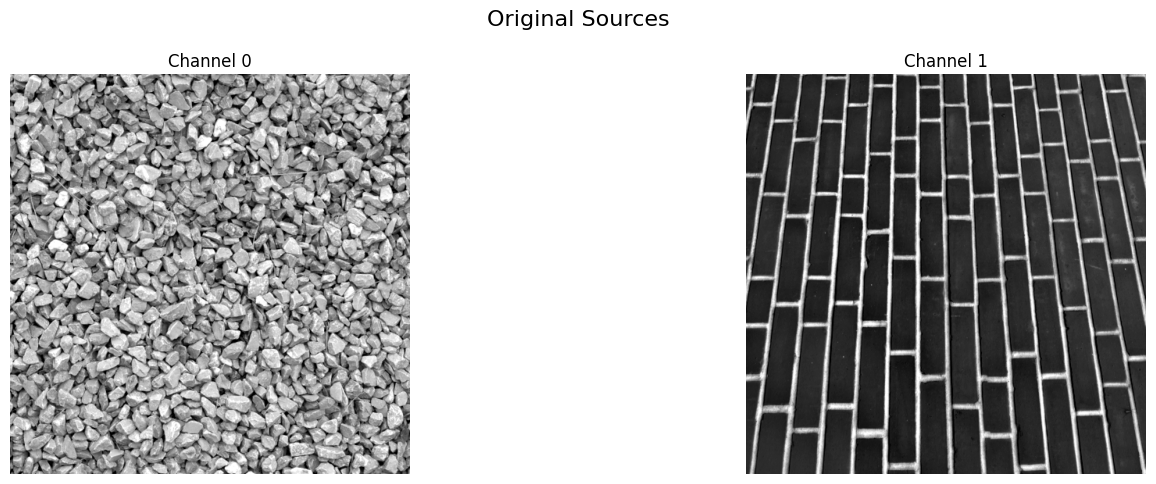

In [5]:
visualize_flattened_images(S, imsize=(min_h, min_w), title="Original Sources")

In [6]:
np.random.seed(0)
N = S.shape[1]
NumberofSources = S.shape[0]
NumberofMixtures = NumberofSources + 2

print("The following is the correlation matrix of sources")
display_matrix(np.corrcoef(S))

# # Generate Mxr random mixing from i.i.d N(0,1)
A = np.random.uniform(low=0.0, high=1.0, size = (NumberofMixtures, NumberofSources)) # Random Uniform mixing matrix
# # A, NumberofMixtures = ortho_group.rvs(dim=NumberofSources), NumberofSources # Random orthogonal mixing matrix
X_noNoise = np.dot(A, S)

A, X_noNoise = WSM_Mixing_Scenario(S, NumberofMixtures, INPUT_STD = 0.5)

SNR = 30
X = addWGN(X_noNoise, SNR)

SNRinp = 10 * np.log10(
    np.sum(np.mean(X_noNoise ** 2, axis=1))
    / np.sum(np.mean((X_noNoise - X)**2, axis=1))
)
print("The following is the mixture matrix A")
display_matrix(A)
print("Input SNR is : {}".format(SNRinp))
S.var(1), X.var(1)

The following is the correlation matrix of sources


<IPython.core.display.Math object>

The following is the mixture matrix A


<IPython.core.display.Math object>

Input SNR is : 30.00036555947429


(array([0.10677232, 0.13091933]),
 array([0.2502456 , 0.25029633, 0.25032914, 0.25040662]))

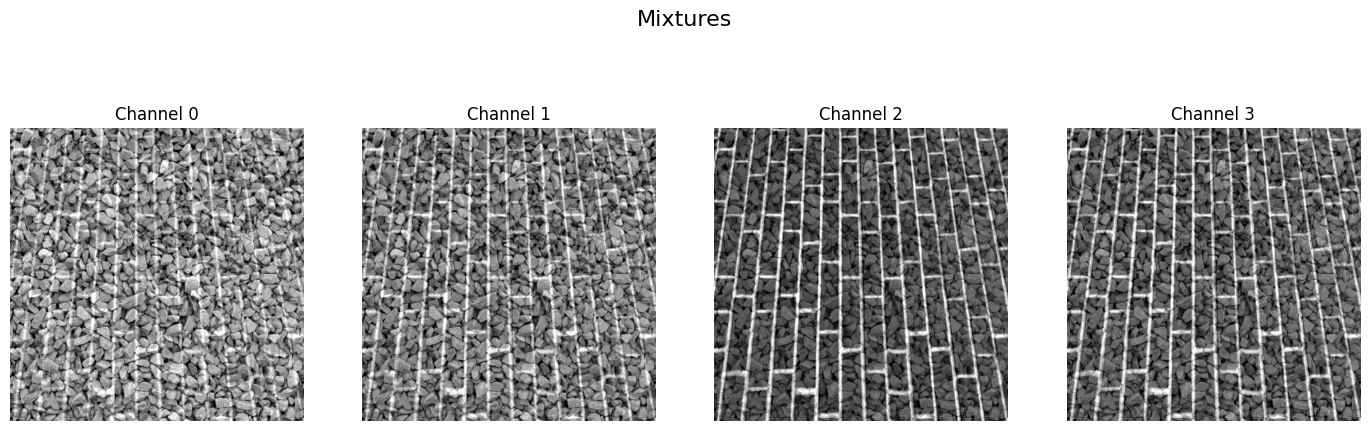

In [7]:
visualize_flattened_images(X, imsize=(min_h, min_w), title="Mixtures")

# Hyperparameters

In [8]:
L = .1*np.eye(NumberofSources)
W = np.eye(NumberofSources, NumberofMixtures)

lambda_predictive = 1000
muW = 50 * 1e-4 * 2
synaptic_lr_decay_divider=5000
lambdaL = 1 - 0.0001

neural_lr_start = 0.1
neural_lr_stop = 1e-4
neural_dynamics_iterations = 100
debug_iteration_point = 10000

n_epochs = 1

# Neural Network Implementation

In [9]:
@njit
def run_neural_dynamics(x, y,
                        W, L,
                        lambda_predictive,
                        neural_dynamics_iterations,
                        neural_lr_start,
                        neural_lr_stop,
                        neural_OUTPUT_COMP_TOL=1e-7):
    """
    Perform activity relaxation (inference) to find the optimal neural state 'y'.
    
    This function implements a fast-timescale gradient descent on the network 
    energy function. It balances two primary forces:
    1. Predictive Coding: Minimizing the error between the current state and 
       the feedforward input (y - Wx).
    2. Lateral Inhibition: Minimizing correlation 
       between neurons using a second-order Taylor approximation of the 
       log-determinant objective.

    Args:
        x (ndarray): Input signal vector.
        y (ndarray): Current neural activity vector (initial guess).
        W (ndarray): Feedforward weight matrix.
        L (ndarray): Lateral weight matrix (representing covariance/correlation).
        lambda_predictive (float): Weighting factor for the predictive error term.
        neural_dynamics_iterations (int): Maximum steps for activity relaxation.
        neural_lr_start (float): Initial step size for activity updates.
        neural_lr_stop (float): Minimum floor for the decaying step size.
        neural_OUTPUT_COMP_TOL (float): Convergence threshold for early exit.

    Returns:
        ndarray: The relaxed neural activity vector 'y'.
    """
    
    # Pre-calculate the feedforward drive (projection of input into latent space)
    yke = np.dot(W, x)
    
    # Extract diagonal (variances) and off-diagonal (covariances) from L
    L_diag = np.diag(L)
    L_off_diag = L - np.diag(L_diag)
    
    for j in range(neural_dynamics_iterations):
        # Time-decaying step size (simulating cooling or annealing)
        mu_y = max(neural_lr_start / (j + 1), neural_lr_stop)
        y_old = y.copy()
        
        # 1. Predictive Error Term: Measures mismatch between activity and input
        error = y - yke
        
        # 2. Lateral Term: Implements normalized decorrelation
        # (np.dot(L_off_diag, y / L_diag)) / L_diag corresponds to our derivation:
        # C_ij * z_j / (V_i * V_j). The '- 2 * y' term acts as the expansion/gain force.
        lateral = (np.dot(L_off_diag, y / L_diag) - 2 * y) / L_diag
        
        # Combine gradients: Total force acting on the neural state
        grady = lambda_predictive * error + lateral
        
        # Gradient descent step
        y = y - mu_y * grady
        
        # Biological constraint: Firing rates are often bounded (activation function)
        y = np.clip(y, -1, 1)
        
        # Convergence check: Exit if the activity has stabilized
        if np.linalg.norm(y - y_old) < neural_OUTPUT_COMP_TOL * np.linalg.norm(y):
            break
            
    return y

In [10]:
samples = N
idx = np.random.permutation(samples)  # random permutation. Probably not very helpful!
# idx = np.arange(S.shape[1])
for epoch_idx in range(n_epochs):
    print("Epoch {} is running".format(epoch_idx + 1))
    for i_sample in tqdm(range(samples)):
        if ((i_sample % debug_iteration_point) == 0) | (
                            i_sample == samples - 1
                        ):
            Y_ = W @ X
            Y_ = signed_and_permutation_corrected_sources(S, Y_) # Find sign and permutation ambiguity
            coef_ = ((Y_ * S).sum(axis=1) / (Y_ * Y_).sum(axis=1)).reshape(-1, 1) # Find if the extracted signals need some amplification! The networks learned weight may need amplification due to lateral connections during the neural dynamics!
            Y_ = coef_ * Y_
    
            print("Signal-to-Interference-and-Noise-Ratio (SINR): {}".format(ComputeSINR(S, Y_)))
            print("Component Signal-to-Noise-Ratio (SNR) Values : {}\n".format(ComputeSNR(S, Y_)))
        x_current = X[:, idx[i_sample]]
        y = np.zeros(NumberofSources)
        # y = W @ x_current  # THIS INITIALIZATION DOES NOT HELP AT ALL! ZERO INITIALIZATION WORKS THE BEST
        y = run_neural_dynamics(x_current, y, W, L, neural_dynamics_iterations, lambda_predictive, neural_lr_start, neural_lr_stop)
        e = y - W @ x_current
        muW_ = np.max(
                    [
                        muW
                        / (1 + np.log(2 + (i_sample // synaptic_lr_decay_divider))),
                        1e-8,
                    ]
                )
    
        W = W + muW_ * np.outer(e, x_current)
        L = lambdaL * L + (1 - lambdaL) * np.outer(y, y)
        # np.fill_diagonal(L, 1) # If we want the variances to be equal to 1 all the time!!

Epoch 1 is running


  0%|          | 0/262144 [00:00<?, ?it/s]

Signal-to-Interference-and-Noise-Ratio (SINR): 3.085425037581226
Component Signal-to-Noise-Ratio (SNR) Values : [5.49623244 2.34591295]



/tmp/ipykernel_1287806/2137231377.py:36: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float64, 2, 'C', False, aligned=True), Array(float64, 1, 'A', False, aligned=True))
  yke = np.dot(W, x)
  5%|▍         | 12608/262144 [00:09<01:18, 3166.76it/s]

Signal-to-Interference-and-Noise-Ratio (SINR): 5.679576020064278
Component Signal-to-Noise-Ratio (SNR) Values : [9.4289508  4.84719837]



...

Signal-to-Interference-and-Noise-Ratio (SINR): 17.391496493686216
Component Signal-to-Noise-Ratio (SNR) Values : [13.10659696 26.72544826]



 97%|█████████▋| 254829/262144 [00:19<00:00, 26896.87it/s]

Signal-to-Interference-and-Noise-Ratio (SINR): 17.97062867424658
Component Signal-to-Noise-Ratio (SNR) Values : [13.70856413 27.05427636]



100%|██████████| 262144/262144 [00:20<00:00, 13082.02it/s]

Signal-to-Interference-and-Noise-Ratio (SINR): 17.523186686069778
Component Signal-to-Noise-Ratio (SNR) Values : [13.24386212 26.78788467]

Signal-to-Interference-and-Noise-Ratio (SINR): 17.03144624371857
Component Signal-to-Noise-Ratio (SNR) Values : [12.72128617 26.66753488]



In [11]:
display_matrix(L)

<IPython.core.display.Math object>

In [12]:
display_matrix(W)

<IPython.core.display.Math object>

In [13]:
Y_ = W @ X
Y_ = signed_and_permutation_corrected_sources(S, Y_) # Find sign and permutation ambiguity
coef_ = ((Y_ * S).sum(axis=1) / (Y_ * Y_).sum(axis=1)).reshape(-1, 1) # Find if the extracted signals need some amplification! The networks learned weight may need amplification due to lateral connections during the neural dynamics!
Y_ = coef_ * Y_

print("Signal-to-Interference-and-Noise-Ratio (SINR): {}".format(ComputeSINR(S, Y_)))
print("Component Signal-to-Noise-Ratio (SNR) Values : {}\n".format(ComputeSNR(S, Y_)))

Signal-to-Interference-and-Noise-Ratio (SINR): 17.030207403348076
Component Signal-to-Noise-Ratio (SNR) Values : [12.72007089 26.66634432]



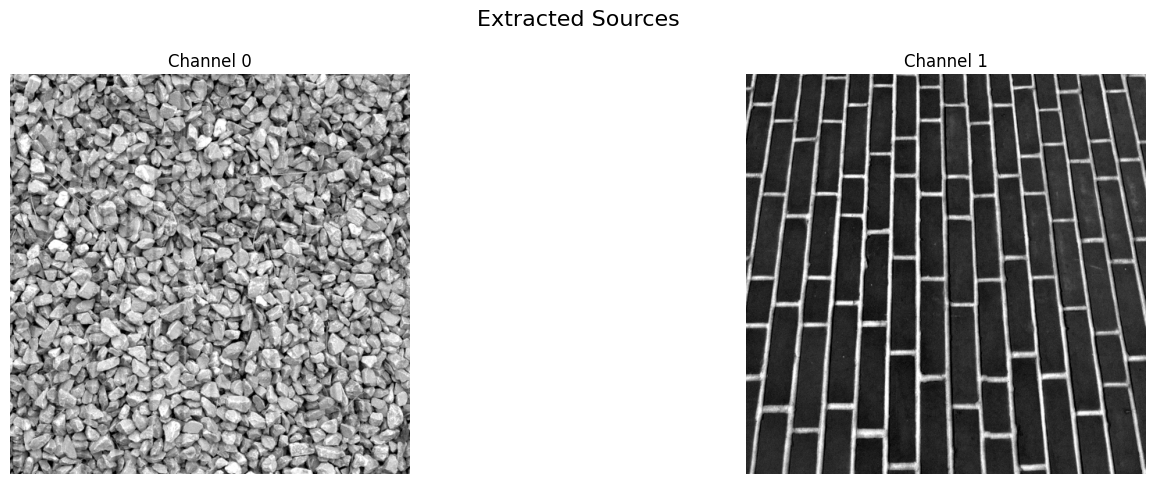

In [14]:
visualize_flattened_images(Y_, imsize=(min_h, min_w), title="Extracted Sources")